In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import matplotlib.colors as mcolors
from scipy.stats import binned_statistic_2d

#from mcs_shared import ALL_FLIGHT_DATES, load_isnobal_depth, load_als_depth

In [2]:
RESOLUTION = 10
ASPECT_BIN_COUNT = 9
ELEVATION_BIN_COUNT = 11

# Generate data
## DEM from original resolution
```bash
gdal raster reproject --resolution 10,10 --bbox 601558.000,4862467.500,609431.500,4870872.500 --resampling cubic --overwrite --co COMPRESS=LZW --co PREDICTOR=2 --co TILED=YES --input ../orig/MCS_REFDEM_32611.tif --output MCS_REFDEM_32611_10m.tif
```
## DEM for flight
```bash
gdal raster reproject --overwrite --bbox 601558.000,4862467.500,609431.500,4870872.500 MCS_REFDEM_32611_10m.tif pattern_flight_area.vrt
```
## Aspect
```bash
gdal raster aspect --overwrite MCS_flight_area_dem.vrt MCS_flight_area_aspect.tif
```

In [3]:
with rasterio.open(
    f"/bsushare/hpmarshall-shared/jmeyer/MCS-ALS-snowdepth/{RESOLUTION}m_base/MCS_flight_area_dem.vrt",
) as dem_file:
    elevation_2d = dem_file.read(1)

elev_min = np.floor(np.nanmin(elevation_2d[elevation_2d > 0]) / 100) * 100
elev_max = np.ceil(np.nanmax(elevation_2d) / 100) * 100
elev_bins = np.linspace(elev_min, elev_max, ELEVATION_BIN_COUNT)

with rasterio.open(
    f"/bsushare/hpmarshall-shared/jmeyer/MCS-ALS-snowdepth/{RESOLUTION}m_base/MCS_flight_area_aspect.tif",
) as dem_file:
    aspect_2d = dem_file.read(1)

aspect_bins = np.linspace(0, 360, ASPECT_BIN_COUNT) 

In [11]:
def load_flight(date):
    als_flight = load_als_depth(date, RESOLUTION).filled(np.nan)
    mask = ~np.isnan(als_flight)
    als_flight = als_flight[mask]
    
    isnobal = load_isnobal_depth(date, RESOLUTION)[mask]
    
    data = isnobal - als_flight
    elevation = elevation_2d[mask]
    aspect = aspect_2d[mask]
    
    # Calculate the mean for each aspect/elevation bin
    statistic, x_edge, y_edge, _bin_number = binned_statistic_2d(
        aspect, 
        elevation, 
        data, 
        statistic='mean', 
        bins=[aspect_bins, elev_bins]
    )

    return statistic

def plot_flight(date):
    data = load_flight(date)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    ax.set_theta_zero_location('N')  # North at top
    ax.set_theta_direction(-1)       # Clockwise
    
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    cmap = plt.cm.coolwarm_r

    # Make a hole in the middle for easier reading of higher values
    inner_val = elev_max + 100 
    # Put the highest in the middle
    ax.set_rorigin(inner_val)

    # Sections for each ring
    width_deg = 360 / (ASPECT_BIN_COUNT - 1)
    width = np.deg2rad(width_deg)
    theta_centers = np.deg2rad(np.arange(0, 360, width_deg))
    
    for i, t in enumerate(theta_centers):
        for j in range(ELEVATION_BIN_COUNT - 1):
            val = data[i, j]
            color = 'whitesmoke' if np.isnan(val) else cmap(norm(val))
            
            ax.bar(
                x=t,
                height=elev_bins[j+1] - elev_bins[j], 
                bottom=elev_bins[j], 
                width=width,
                color=color,
                edgecolor='none'
            )
    
    ax.grid(True, axis='both', color='black', linewidth=1.5, zorder=3)

    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(
        ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], 
        fontsize=12, 
        fontweight='bold', 
        color='black'
    )
    
    ax.set_ylim(inner_val, elev_min)
    ax.set_yticks(elev_bins)
    ax.set_rlabel_position(10)
    x_labels = np.empty_like(elev_bins, dtype=object)
    x_labels[0] = f"{int(elev_min)} m"
    ax.set_yticklabels(
        x_labels, 
        fontsize=12, 
        color='black',
    )

    # Center "dot"
    ax.plot(0, inner_val, 'o', color='white', markersize=32, zorder=5)
    
    # Scale Bar
    scale_ax = fig.add_axes([0.04, 0.35, 0.02, 0.3])
    scale_ax.set_ylim(elev_max, elev_min)
    scale_ax.set_yticks(elev_bins)
    scale_ax.set_yticklabels([f"{int(v)}" for v in elev_bins], fontsize=12)
    scale_ax.set_xticks([])
    scale_ax.grid(True, axis='y', color='black', linestyle='-', linewidth=0.8)
    scale_ax.set_axisbelow(False)
    scale_ax.set_ylabel('Elevation (m)', fontweight='bold', fontsize=12)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.1, extend='both')
    cbar.set_label('Difference (m)', fontsize=14)
    
    ax.set_title(pd.to_datetime(date).strftime("%Y-%m-%d"), va='bottom', fontsize=14)
    
    plt.show()

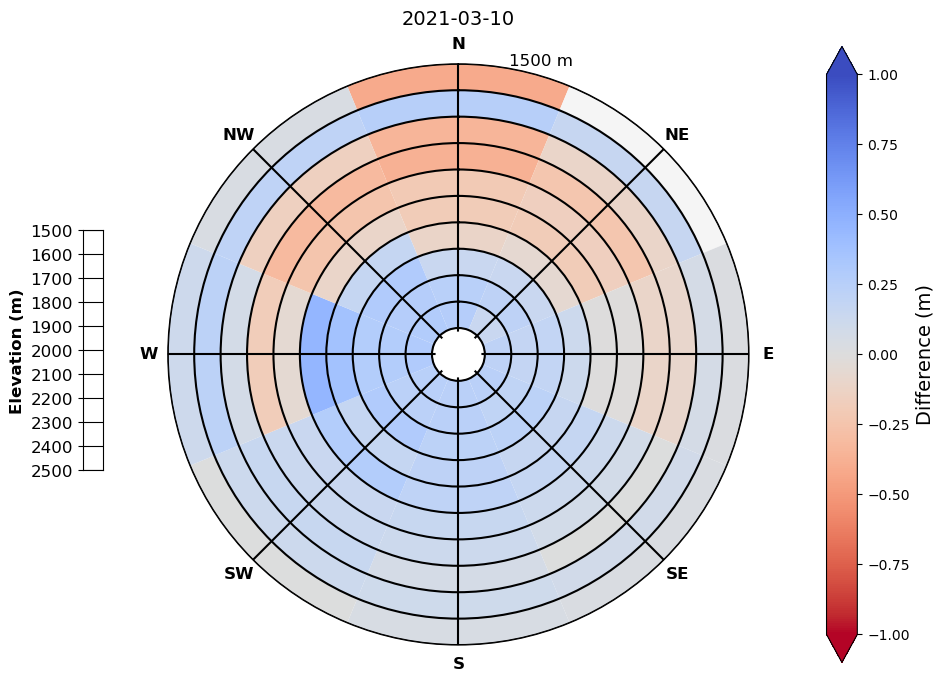

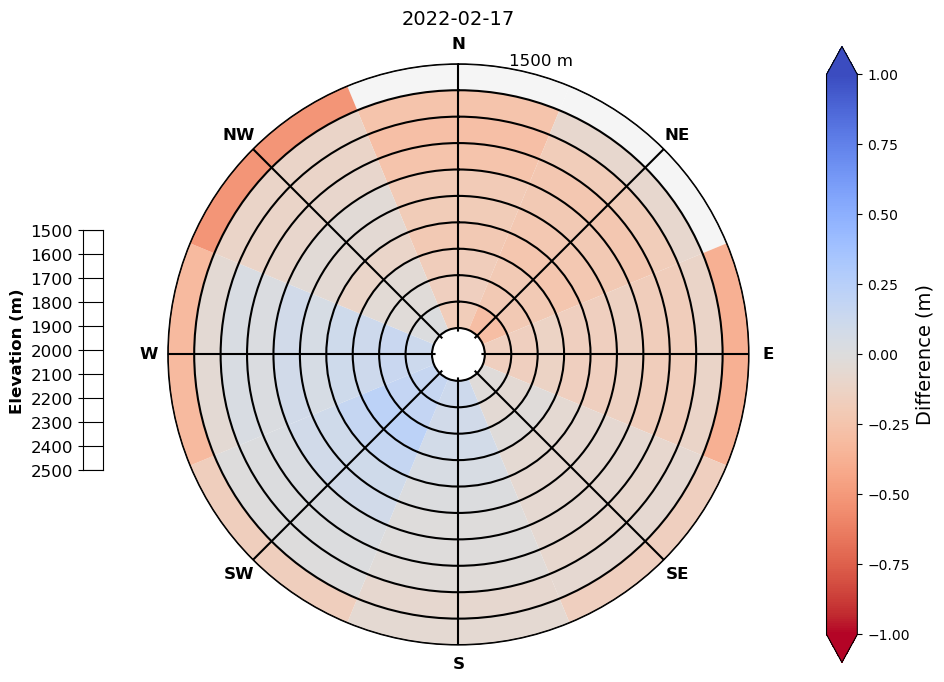

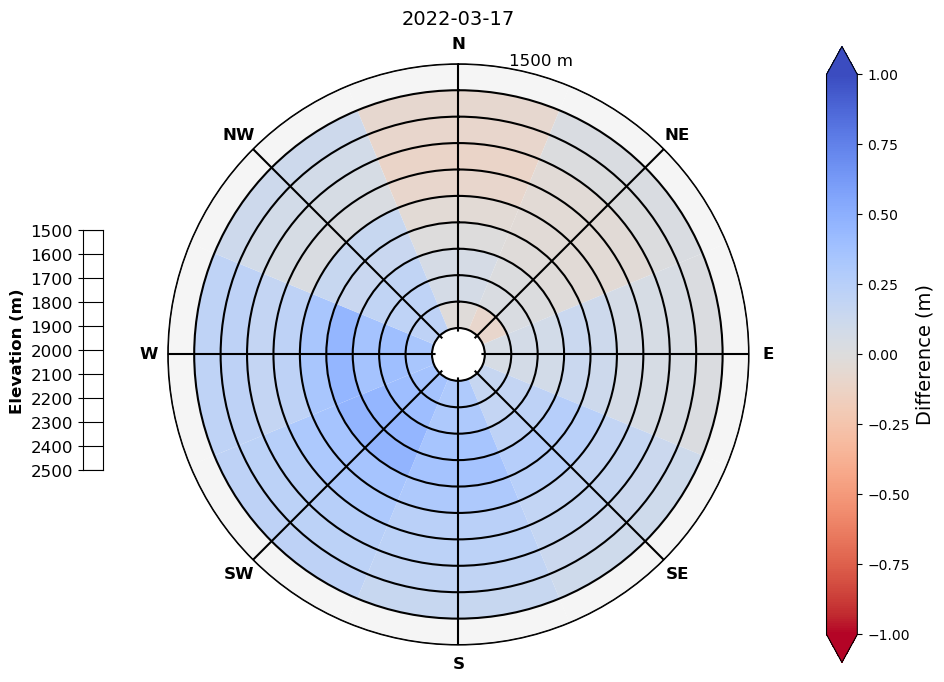

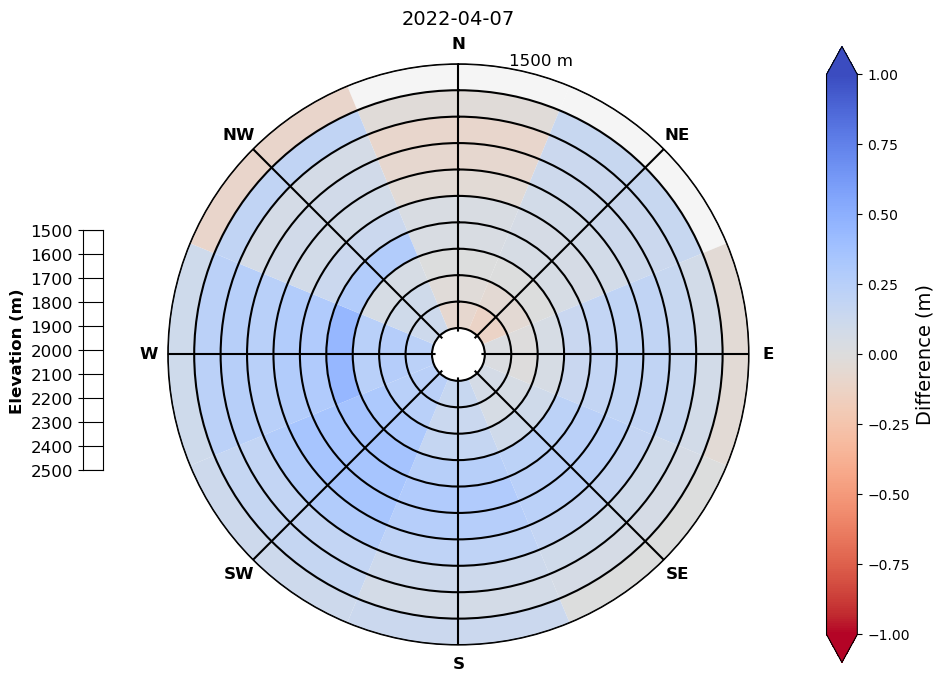

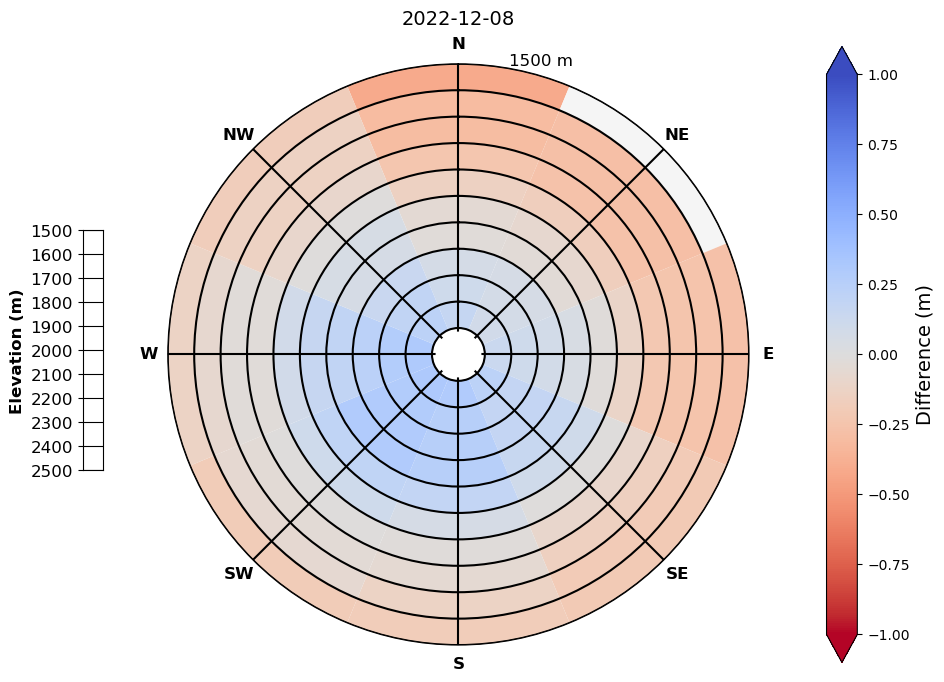

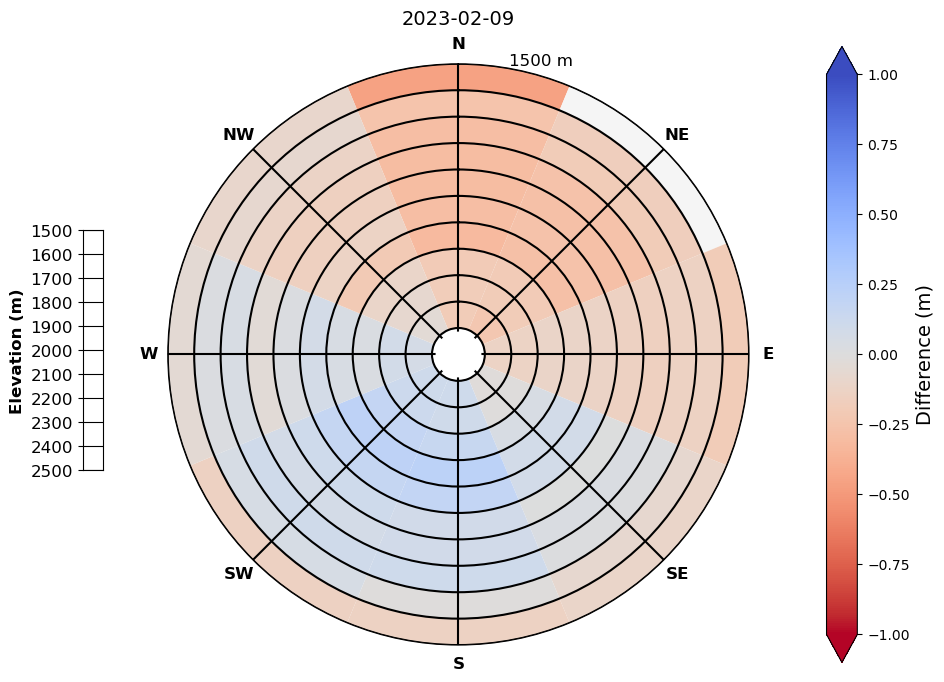

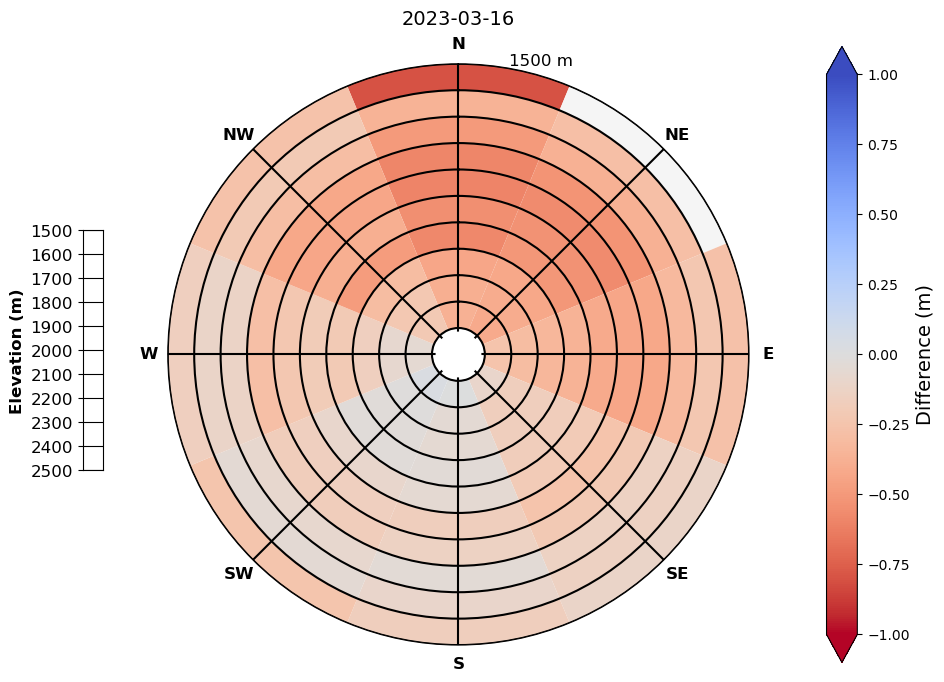

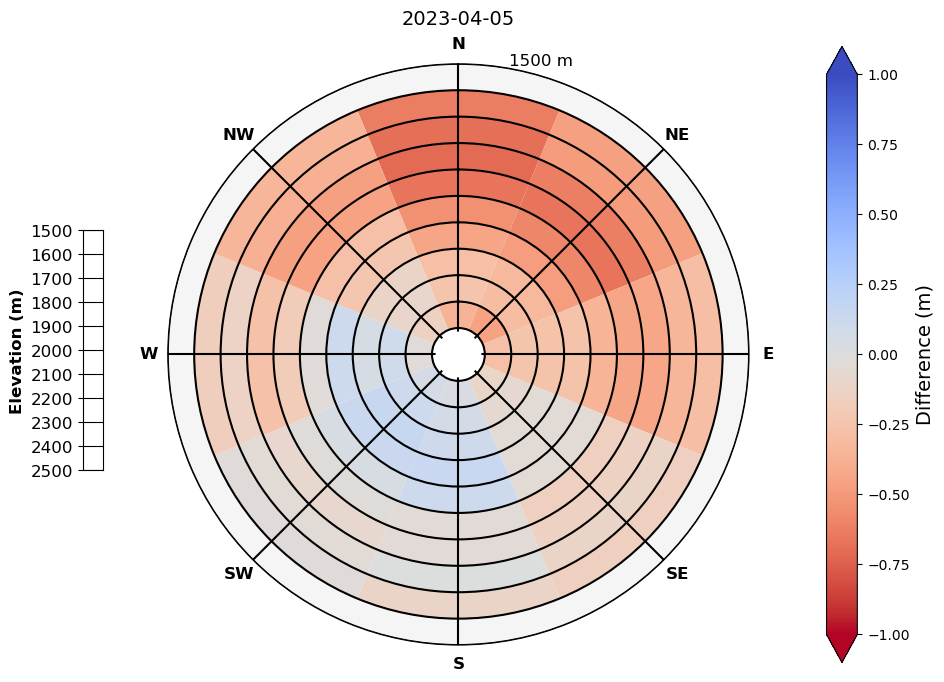

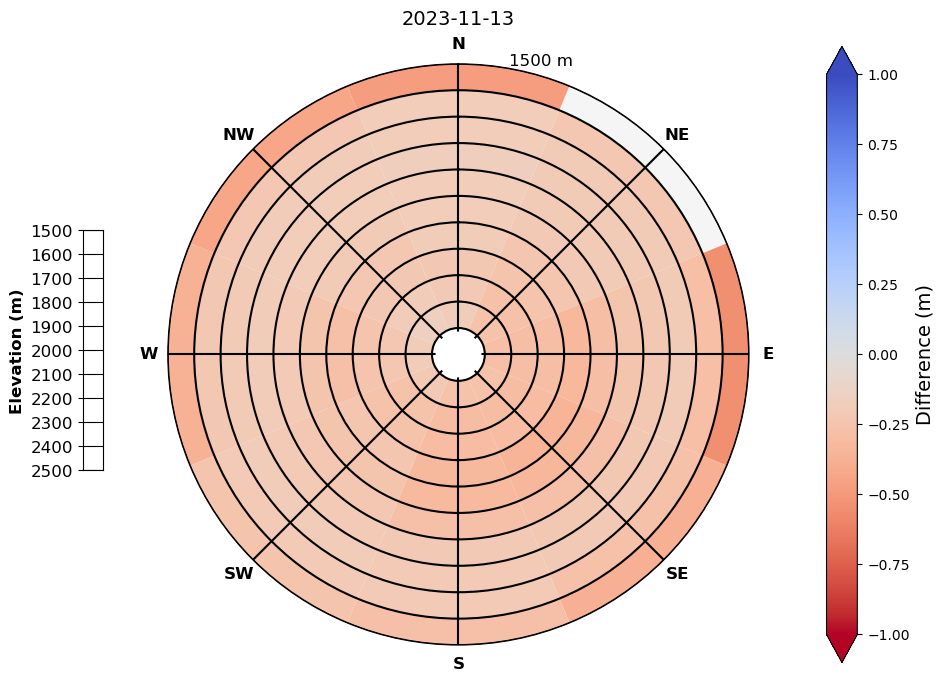

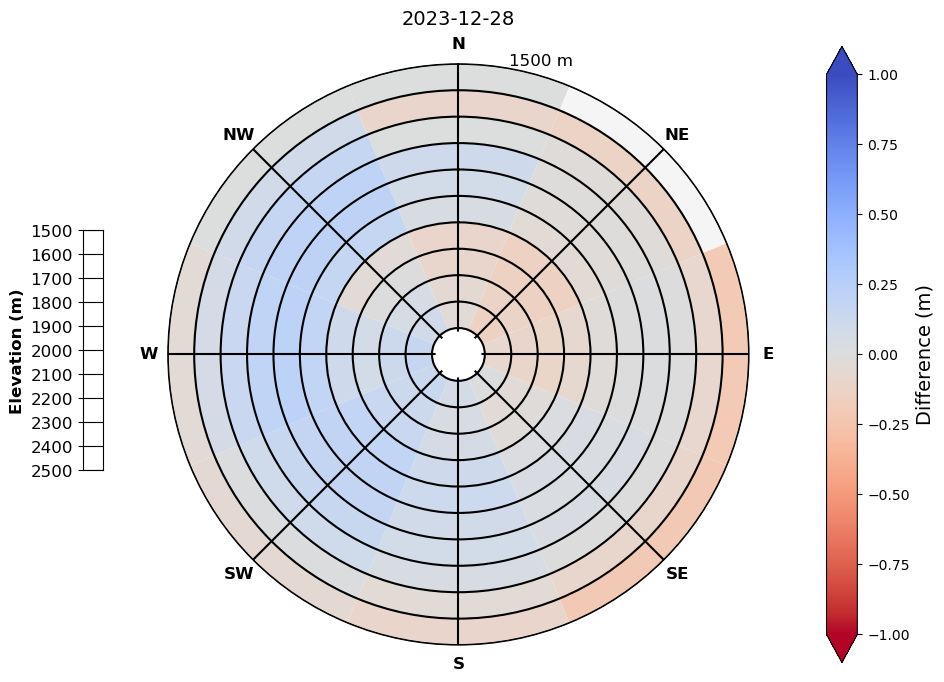

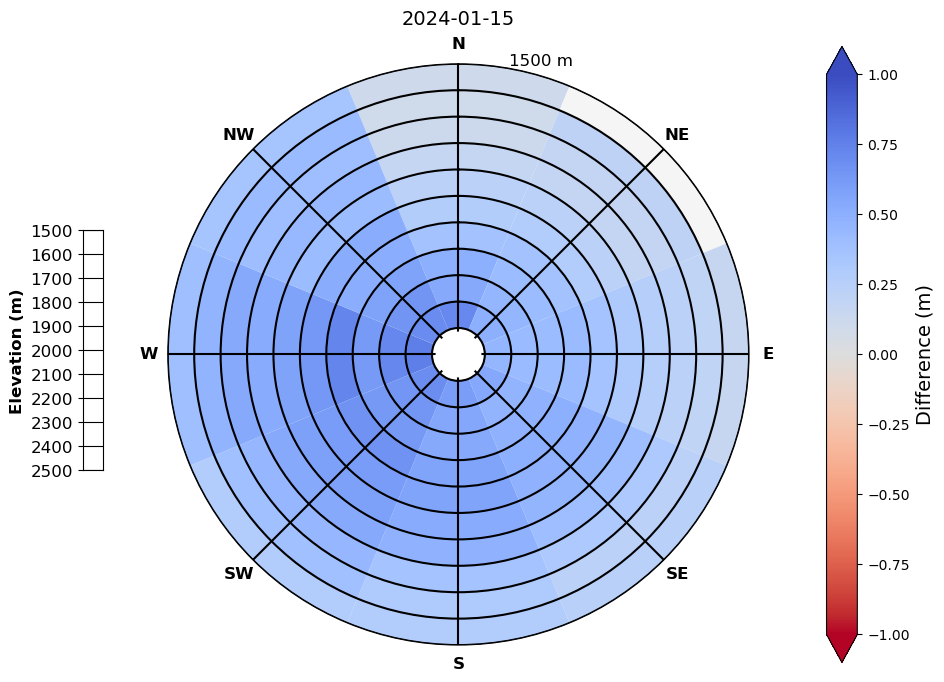

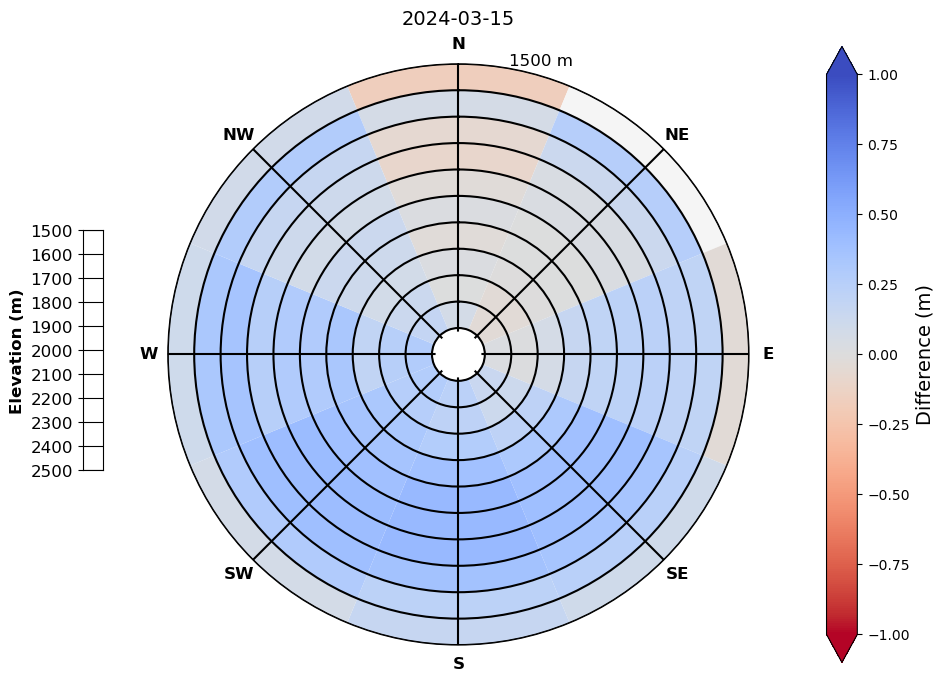

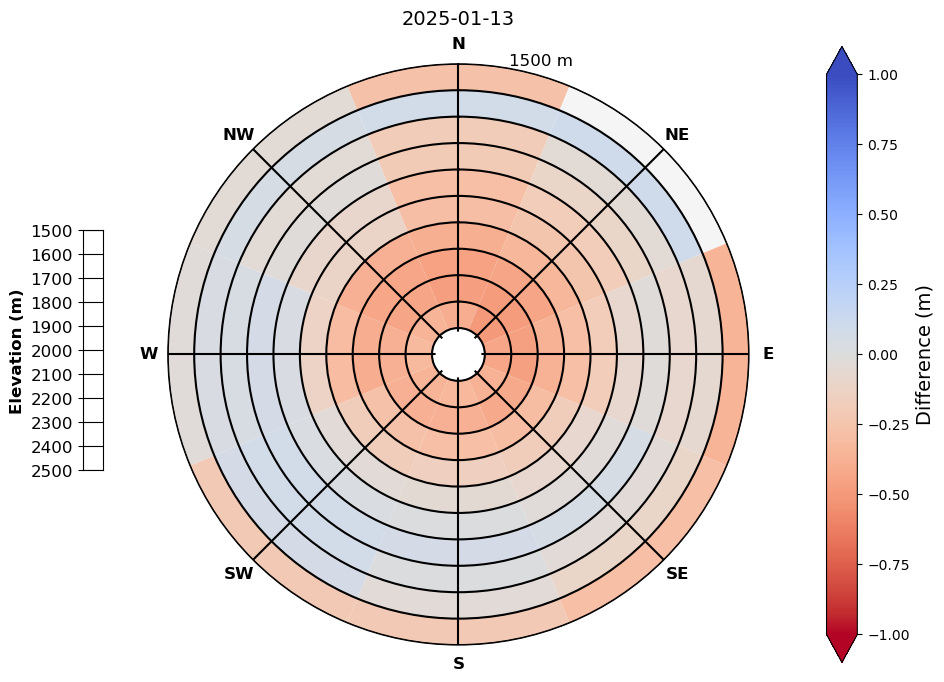

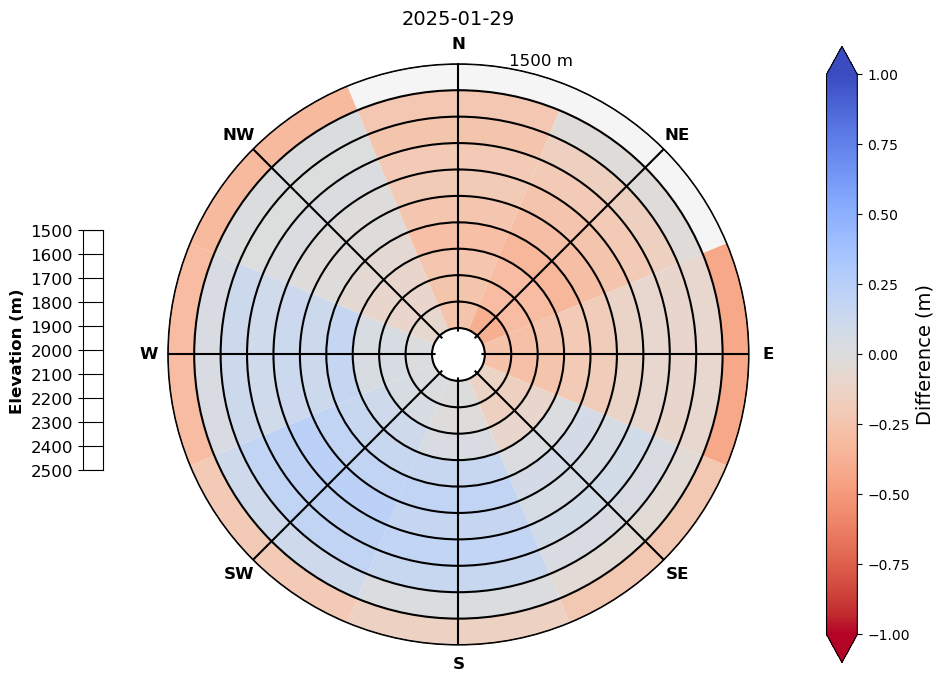

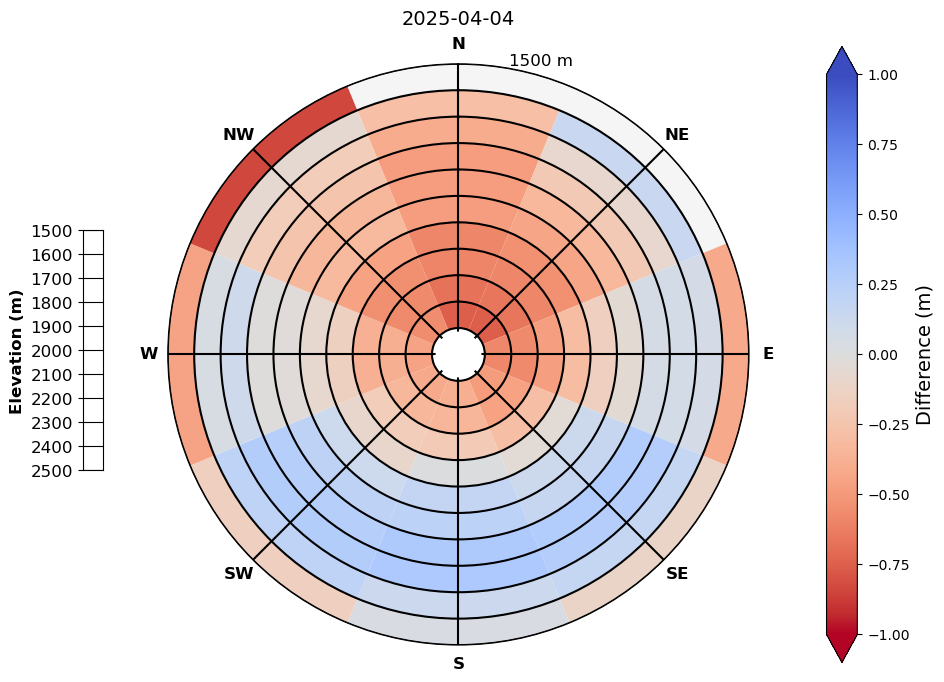

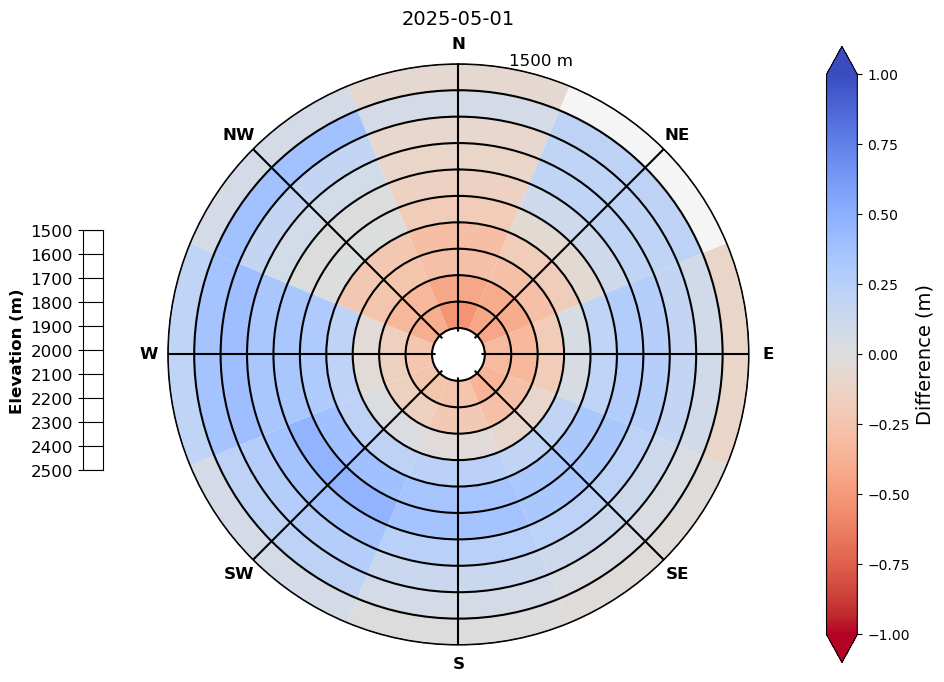

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [12]:
[plot_flight(date) for date in ALL_FLIGHT_DATES]